### Exploratory Work

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import requests
import plotly.graph_objects as go
import warnings
from datetime import datetime, timedelta
from typing import Dict, Any
import json
import os

warnings.filterwarnings("ignore")

<Axes: >

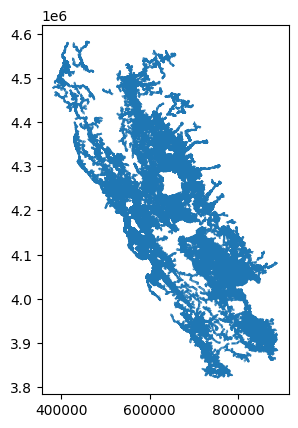

In [26]:
feeder_shp = gpd.read_file("data/pge_feeder_shapefile/FeederDetail.shp")
feeder_shp.plot()

In [27]:
feeder_shp.head()


,OBJECTID,Substation,FeederID,Feeder_Nam,Nominal_Vo,Load_Profi,ResCust,ComCust,IndCust,AgrCust,OthCust,Existing_D,Queued_DG,Total_DG,Division,VOLTNUM,Publish,Last_Updat,SHAPE_Leng,geometry
0,1,DEVILS DEN,253451101,DEVILS DEN 1101,12kV,Yes,11,21,9,34,7,432,432,864,Fresno,12,1,20260128175325,77768.170947,"MULTILINESTRING ((773016.169 3970528.093, 7730..."
1,2,BELLEVUE,043182101,BELLEVUE 2101,21kV,No,1063,135,12,71,6,4220,4140,8360,Sonoma,21,1,20260128175325,127499.985855,"MULTILINESTRING ((531789.172 4248565.99, 53178..."
2,3,SF K,022130411,SF K 0411,4.16kV,No,1410,141,7,0,2,110,20,130,San francisco,4,1,20250602012105,3855.639645,"MULTILINESTRING ((544614.163 4180852.813, 5446..."
3,4,MOUNTAIN VIEW,082031114,MOUNTAIN VIEW 1114,12kV,Yes,322,86,28,0,2,1412,1443,2855,De Anza,12,1,20260128120317,12772.342653,"MULTILINESTRING ((581373.794 4136022.678, 5813..."
4,5,MOUNTAIN VIEW,082031109,MOUNTAIN VIEW 1109,12kV,Yes,1557,57,25,0,13,5786,5979,11765,De Anza,12,1,20260128120317,31247.582428,"MULTILINESTRING ((582284.804 4137717.463, 5822..."


In [28]:
feeder_shp.columns.tolist()

['OBJECTID',
 'Substation',
 'FeederID',
 'Feeder_Nam',
 'Nominal_Vo',
 'Load_Profi',
 'ResCust',
 'ComCust',
 'IndCust',
 'AgrCust',
 'OthCust',
 'Existing_D',
 'Queued_DG',
 'Total_DG',
 'Division',
 'VOLTNUM',
 'Publish',
 'Last_Updat',
 'SHAPE_Leng',
 'geometry']

<Axes: >

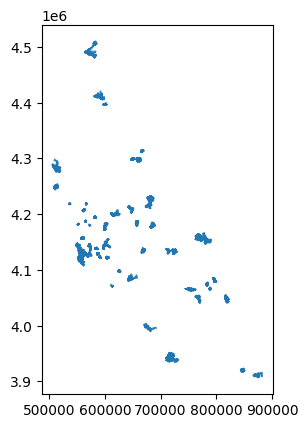

In [29]:
# List of representative circuits on the PG&E HFP portal
circuit_ids = [
    "012041131", "012640401", "013532223", "013921103", "014052103",
    "014321101", "014592108", "022011162", "024011104", "024040403",
    "024091102", "024101103", "024131103", "042211101", "042450414",
    "042571101", "042891102", "082031112", "082831109", "082952113",
    "083182102", "083371113", "083611114", "083771102", "083892102",
    "102841106", "103081106", "103351101", "152442109", "152561107",
    "152701109", "162611702", "162611703", "162611704", "162991101",
    "163121106", "163191711", "163191714", "163251101", "163722110",
    "163912104", "182191101", "182381104", "182492104", "183052109",
    "252051104", "252051114", "252062112", "252281111", "252711104",
    "252802101", "253611106", "253882109", "253911102", "254081104",
    "254091104", "254411105", "254452101", "254572101",
]

filtered_feeders = feeder_shp[feeder_shp["FeederID"].isin(circuit_ids)]
filtered_feeders.plot()

<Axes: >

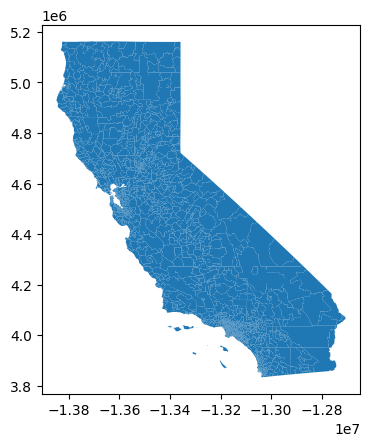

In [30]:
zipcode_shp = gpd.read_file("data/ca_zipcode_shapefile/zip_poly.shp")
zipcode_shp.plot()

In [31]:
zipcode_shp.head()

,ZIP_CODE,PO_NAME,STATE,POPULATION,POP_SQMI,SQMI,geometry
0,00012,Mt Meadows Area,CA,0,0.00,30.92,"POLYGON ((-13474731.772 4903282.532, -13474716..."
1,00016,Sequoia National Forest,CA,26,0.66,39.33,"POLYGON ((-13189602.036 4239987.11, -13189590...."
2,00017,Northeast Fresno County,CA,0,0.00,564.41,"POLYGON ((-13267161.108 4503250.18, -13267159...."
3,00018,Los Padres Ntl Forest,CA,0,0.00,90.83,"POLYGON ((-13255913.164 4096587.096, -13255912..."
4,00019,Lassen Ntl Forest,CA,17,0.04,412.59,"POLYGON ((-13398996.781 4949420.395, -13398824..."


In [32]:
zipcode_shp.columns.tolist()

['ZIP_CODE', 'PO_NAME', 'STATE', 'POPULATION', 'POP_SQMI', 'SQMI', 'geometry']

In [33]:
common_cols = set(filtered_feeders.columns).intersection(zipcode_shp.columns) - {"geometry"}
feeders_renamed = filtered_feeders.rename(columns={c: f"feeder_{c}" for c in common_cols})
zipcodes_renamed = zipcode_shp.rename(columns={c: f"zip_{c}" for c in common_cols})

feeders_proj = feeders_renamed.to_crs(zipcodes_renamed.crs)
joined_df = gpd.sjoin(feeders_proj, zipcodes_renamed, how="inner", predicate="intersects")

joined_df = joined_df.drop(columns=["geometry"]).merge(
    zipcodes_renamed[["geometry"]], left_on="index_right", right_index=True
)
joined_df = gpd.GeoDataFrame(joined_df, geometry="geometry")

In [34]:

joined_df = joined_df.dropna()
joined_df.head()

,OBJECTID,Substation,FeederID,Feeder_Nam,Nominal_Vo,Load_Profi,ResCust,ComCust,IndCust,AgrCust,...,Last_Updat,SHAPE_Leng,index_right,ZIP_CODE,PO_NAME,STATE,POPULATION,POP_SQMI,SQMI,geometry
59,60,MANTECA,162611704,MANTECA 1704,17kV,No,2623,150,62,0,...,20260128120319,42544.125043,1326,95336,Manteca,CA,47707,1242.69,38.39,"POLYGON ((-13499290.41 4562618.703, -13499281...."
86,87,ASHLAN AVE,252051104,ASHLAN AVE 1104,12kV,No,1610,161,73,0,...,20260128120319,25513.159961,935,93706,Fresno,CA,40167,259.38,154.86,"POLYGON ((-13363197.546 4384088.769, -13363192..."
86,87,ASHLAN AVE,252051104,ASHLAN AVE 1104,12kV,No,1610,161,73,0,...,20260128120319,25513.159961,945,93728,Fresno,CA,16411,5488.63,2.99,"POLYGON ((-13341009.233 4405609.901, -13341008..."
86,87,ASHLAN AVE,252051104,ASHLAN AVE 1104,12kV,No,1610,161,73,0,...,20260128120319,25513.159961,934,93705,Fresno,CA,40433,7943.61,5.09,"POLYGON ((-13341265.157 4411953.954, -13341265..."
86,87,ASHLAN AVE,252051104,ASHLAN AVE 1104,12kV,No,1610,161,73,0,...,20260128120319,25513.159961,940,93722,Fresno,CA,87359,4208.04,20.76,"POLYGON ((-13352073.946 4415943.091, -13352048..."


<Axes: >

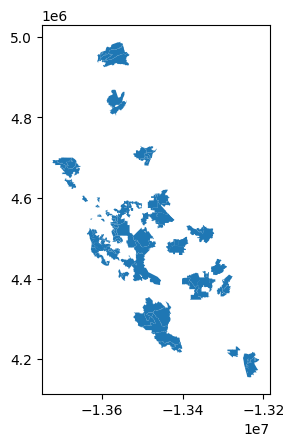

In [35]:
joined_df.plot()

In [36]:
ev_sales_df = pd.read_csv("data/ca_ev_sales_zip_level.csv")
ev_sales_df.head()

,Data_Year,Quarter,ZIP,FUEL_TYPE,Number of Vehicles
0,2008,3,94025,Electric,1
1,2008,3,94062,Electric,1
2,2008,3,94066,Electric,1
3,2008,3,94105,Electric,1
4,2008,3,94301,Electric,1


In [37]:
ev_sales_df.columns.tolist()

['Data_Year', 'Quarter', 'ZIP', 'FUEL_TYPE', 'Number of Vehicles']

In [38]:
ev_count_df = (
    ev_sales_df[
        (ev_sales_df["Data_Year"].between(2015, 2025)) &
        (ev_sales_df["FUEL_TYPE"] == "Electric")
    ]
    .groupby("ZIP")["Number of Vehicles"]
    .sum()
    .reset_index(name="ev_count")
)
ev_count_df.head()

,ZIP,ev_count
0,90001,433
1,90002,365
2,90003,432
3,90004,2551
4,90005,1659


In [45]:
joined_df["ZIP_CODE"] = joined_df["ZIP_CODE"].astype(str)
ev_count_df["ZIP"] = ev_count_df["ZIP"].astype(str)

matched_df = joined_df[["FeederID", "Substation", "Division", "PO_NAME", "ZIP_CODE", "geometry"]].merge(
    ev_count_df, left_on="ZIP_CODE", right_on="ZIP"
).drop(columns=["ZIP"])
matched_df.head()

,FeederID,Substation,Division,PO_NAME,ZIP_CODE,geometry,ev_count
0,162611704,MANTECA,Stockton,Manteca,95336,"POLYGON ((-13499290.41 4562618.703, -13499281....",822
1,252051104,ASHLAN AVE,Fresno,Fresno,93706,"POLYGON ((-13363197.546 4384088.769, -13363192...",192
2,252051104,ASHLAN AVE,Fresno,Fresno,93728,"POLYGON ((-13341009.233 4405609.901, -13341008...",105
3,252051104,ASHLAN AVE,Fresno,Fresno,93705,"POLYGON ((-13341265.157 4411953.954, -13341265...",213
4,252051104,ASHLAN AVE,Fresno,Fresno,93722,"POLYGON ((-13352073.946 4415943.091, -13352048...",1387


In [46]:
len(matched_df), matched_df.ev_count.sum()

(159, 280192)

In [50]:
len(ev_count_df), ev_count_df.ev_count.sum()

(2411, 1912430)

In [47]:
top_500_zips = ev_count_df.sort_values("ev_count", ascending=False).head(500)

unmatched_zips = top_500_zips[~top_500_zips["ZIP"].isin(matched_df["ZIP_CODE"])]

zipcode_shp["ZIP_CODE"] = zipcode_shp["ZIP_CODE"].astype(str)
unmatched_with_geom = unmatched_zips.merge(
    zipcode_shp[["ZIP_CODE", "PO_NAME", "geometry"]],
    left_on="ZIP", right_on="ZIP_CODE", how="left"
).dropna(subset=["geometry"])
unmatched_gdf = gpd.GeoDataFrame(unmatched_with_geom, geometry="geometry", crs=zipcode_shp.crs)

feeders_proj = filtered_feeders.to_crs(zipcode_shp.crs)

nearest_result = gpd.sjoin_nearest(
    unmatched_gdf[["ZIP_CODE", "PO_NAME", "ev_count", "geometry"]],
    feeders_proj[["FeederID", "Substation", "Division", "geometry"]],
    how="left"
).drop(columns=["index_right"])

unmatched_df = nearest_result[["FeederID", "Substation", "Division", "PO_NAME", "ZIP_CODE", "geometry", "ev_count"]]
print(f"Top 500 zips: {len(top_500_zips)}, Already matched: {len(top_500_zips) - len(unmatched_zips)}, Newly matched: {len(unmatched_df)}")
unmatched_df.head()

Top 500 zips: 500, Already matched: 53, Newly matched: 446


,FeederID,Substation,Division,PO_NAME,ZIP_CODE,geometry,ev_count
1,253911102,LAMONT,Kern,Irvine,92618,"POLYGON ((-13112858.802 3983718.133, -13112847...",15244
2,024040403,BERESFORD,Peninsula,South San Francisco,94080,"POLYGON ((-13633535.705 4529806.293, -13633535...",13174
3,082831109,MILPITAS,San Jose,Fremont,94538,"MULTIPOLYGON (((-13587116.924 4507636.753, -13...",10395
4,253911102,LAMONT,Kern,Irvine,92620,"POLYGON ((-13111632.873 3989728.553, -13111588...",10246
5,253911102,LAMONT,Kern,Los Angeles,90045,"POLYGON ((-13184595.775 4022319.164, -13184587...",9912


In [48]:
final_data = gpd.GeoDataFrame(
    pd.concat([matched_df, unmatched_df], ignore_index=True),
    geometry="geometry"
)
len(final_data), final_data.ev_count.sum()

(605, 1569106)

In [60]:
final_data.FeederID.nunique(), len(final_data), final_data.ev_count.sum()

(59, 605, 1569106)

In [52]:
final_data.PO_NAME.sort_values().unique()

array(['Agoura Hills', 'Alameda', 'Alamo', 'Alhambra', 'Aliso Viejo',
       'Altadena', 'Anaheim', 'Antioch', 'Arcadia', 'Arvin', 'Atherton',
       'Atwater', 'Auburn', 'Azusa', 'Bakersfield', 'Baldwin Park',
       'Beaumont', 'Bellflower', 'Belmont', 'Belvedere Tiburon',
       'Berkeley', 'Beverly Hills', 'Bradley', 'Brea', 'Brentwood',
       'Buena Park', 'Burbank', 'Burlingame', 'Burson', 'Calabasas',
       'Camarillo', 'Campbell', 'Canoga Park', 'Canyon Country',
       'Carlsbad', 'Carmichael', 'Carson', 'Castro Valley', 'Castroville',
       'Cathedral City', 'Cerritos', 'Chatsworth', 'Chico', 'Chino',
       'Chino Hills', 'Chula Vista', 'Claremont', 'Cloverdale', 'Clovis',
       'Concord', 'Corona', 'Corona del Mar', 'Costa Mesa', 'Creston',
       'Culver City', 'Cupertino', 'Cypress', 'Daly City', 'Dana Point',
       'Danville', 'Davis', 'Del Mar', 'Diamond Bar', 'Dinuba',
       'Discovery Bay', 'Downey', 'Dublin', 'El Cajon', 'El Cerrito',
       'El Dorado Hills', 

In [61]:
# final_data.to_csv("data/final_data.csv", index=False)
final_data = pd.read_csv("data/final_data.csv", dtype={"FeederID": str})
final_data.head()

,FeederID,Substation,Division,PO_NAME,ZIP_CODE,geometry,ev_count
0,162611704,MANTECA,Stockton,Manteca,95336,POLYGON ((-13499290.409920873 4562618.70270636...,822
1,252051104,ASHLAN AVE,Fresno,Fresno,93706,POLYGON ((-13363197.545687994 4384088.76920996...,192
2,252051104,ASHLAN AVE,Fresno,Fresno,93728,POLYGON ((-13341009.23346359 4405609.901123333...,105
3,252051104,ASHLAN AVE,Fresno,Fresno,93705,"POLYGON ((-13341265.15697292 4411953.95369522,...",213
4,252051104,ASHLAN AVE,Fresno,Fresno,93722,POLYGON ((-13352073.94557047 4415943.090647072...,1387


In [54]:
class GetPGEHourlyPricingData:
    def __init__(self, circuit_id: str, start_date: datetime, end_date: datetime,
                 rate_name: str = "EV2A", verbose: bool = False):
        self.circuit_id = circuit_id
        self.start_date = start_date
        self.end_date = end_date
        self.rate_name = rate_name
        self.verbose = verbose
        self.pricing_data = None

        self.API_URL = "https://pge-pe-api.gridx.com/v1/getPricing"
        self.AVAILABLE_RATES = ["EV2A", "E-TOU-C", "B20P", "E1", "E6"]

        self._validate_inputs()
    # end __init__

    def __repr__(self):
        return f"GetPGEHourlyPricingData(Circuit={self.circuit_id}, Rate={self.rate_name}, Records={len(self.pricing_data) if self.pricing_data is not None else 0})"
    # end __repr__

    def _validate_inputs(self):
        if self.start_date >= self.end_date:
            raise ValueError("Start date must be before end date")

        min_date = datetime(2024, 6, 1)
        max_date = datetime.now() + timedelta(days=7)

        if self.start_date < min_date:
            raise ValueError(f"Start date cannot be before {min_date.strftime('%Y-%m-%d')}")

        if self.end_date > max_date:
            raise ValueError(f"End date cannot be more than 7 days from today")

        if self.rate_name not in self.AVAILABLE_RATES:
            raise ValueError(f"Rate name '{self.rate_name}' not supported. Available rates: {self.AVAILABLE_RATES}")
    # end _validate_inputs

    def run(self):
        try:
            self._get_pricing_from_gridx()
        except Exception as e:
            raise RuntimeError(f"Processing failed: {str(e)}")
    # end run

    def _get_date_chunks(self):
        chunks = []
        current_start = self.start_date

        while current_start < self.end_date:
            chunk_end = min(current_start + timedelta(days=13), self.end_date)
            chunks.append((current_start, chunk_end))
            current_start = chunk_end + timedelta(days=1)

        return chunks
    # end _get_date_chunks

    def _fetch_pricing_for_chunk(self, circuit_id: str, start_date: datetime, end_date: datetime):
        params = {
            "utility": "PGE",
            "market": "DAM",
            "startdate": start_date.strftime("%Y%m%d"),
            "enddate": end_date.strftime("%Y%m%d"),
            "ratename": self.rate_name,
            "representativeCircuitId": circuit_id,
            "program": "CalFUSE"
        }

        try:
            response = requests.get(self.API_URL, params=params, timeout=30)

            if response.status_code != 200:
                return None

            data = response.json()

            if "data" not in data or not data["data"]:
                return None

            pricing_records = []

            for day_data in data["data"]:
                price_details = day_data.get("priceDetails", [])

                for price_record in price_details:
                    timestamp_str = price_record.get("startIntervalTimeStamp")
                    price_str = price_record.get("intervalPrice")

                    if timestamp_str and price_str:
                        timestamp_utc = pd.to_datetime(timestamp_str, utc=True)
                        timestamp_pst = timestamp_utc.tz_convert('US/Pacific').tz_localize(None)
                        price = float(price_str)

                        pricing_records.append({
                            "timestamp": timestamp_pst,
                            "price_per_kwh": round(price, 6)
                        })

            return pricing_records

        except requests.exceptions.RequestException:
            return None
    # end _fetch_pricing_for_chunk

    def _create_full_hourly_range(self):
        hourly_range = pd.date_range(
            start=self.start_date,
            end=self.end_date,
            freq='H',
            tz='US/Pacific'
        ).tz_localize(None)

        return pd.DataFrame({
            'timestamp': hourly_range,
            'price_per_kwh': np.nan
        })
    # end _create_full_hourly_range

    def _get_pricing_from_gridx(self):
        try:
            date_chunks = self._get_date_chunks()
            all_pricing_records = []
            successful_chunks = 0

            for chunk_start, chunk_end in date_chunks:
                chunk_records = self._fetch_pricing_for_chunk(self.circuit_id, chunk_start, chunk_end)
                if chunk_records is not None:
                    all_pricing_records.extend(chunk_records)
                    successful_chunks += 1

            df_complete = self._create_full_hourly_range()

            if all_pricing_records:
                df_data = pd.DataFrame(all_pricing_records)
                df_data = df_data.drop_duplicates(subset=['timestamp'], keep='first')
                df_complete = df_complete.set_index('timestamp')
                df_data = df_data.set_index('timestamp')
                df_complete.update(df_data)
                df_complete = df_complete.reset_index()

            self.pricing_data = df_complete.sort_values("timestamp").reset_index(drop=True)
            data_coverage = (1 - df_complete['price_per_kwh'].isna().sum() / len(df_complete)) * 100
            if self.verbose:
                print(f"Circuit {self.circuit_id}: {successful_chunks}/{len(date_chunks)} chunks, {data_coverage:.1f}% coverage")

        except Exception as e:
            raise RuntimeError(f"Failed to get pricing data: {str(e)}")
    # end _get_pricing_from_gridx

    @property
    def get_summary_stats(self) -> Dict[str, Any]:
        if self.pricing_data is None or self.pricing_data.empty:
            return {"error": "No pricing data available"}

        df = self.pricing_data
        valid_data = df.dropna(subset=['price_per_kwh'])

        if valid_data.empty:
            return {"error": "No valid pricing data available"}

        return {
            "circuit_id": self.circuit_id,
            "rate_name": self.rate_name,
            "date_range": (self.start_date, self.end_date),
            "total_records": len(df),
            "valid_records": len(valid_data),
            "data_coverage_percent": round((len(valid_data) / len(df)) * 100, 1),
            "price_range_per_kwh": (round(valid_data["price_per_kwh"].min(), 6), round(valid_data["price_per_kwh"].max(), 6)),
            "avg_price_per_kwh": round(valid_data["price_per_kwh"].mean(), 6),
            "price_volatility": round(valid_data["price_per_kwh"].std(), 6)
        }
    # end get_summary_stats

In [55]:
sample_circuit = final_data["FeederID"].iloc[0]

pge = GetPGEHourlyPricingData(
    circuit_id=sample_circuit,
    start_date=datetime(2025, 1, 1),
    end_date=datetime(2025, 12, 31),
)
pge.run()
pge.get_summary_stats

{'circuit_id': 162611704,
 'rate_name': 'EV2A',
 'date_range': (datetime.datetime(2025, 1, 1, 0, 0),
  datetime.datetime(2025, 12, 31, 0, 0)),
 'total_records': 8737,
 'valid_records': 8736,
 'data_coverage_percent': 100.0,
 'price_range_per_kwh': (-0.040774, 1.089231),
 'avg_price_per_kwh': 0.051064,
 'price_volatility': 0.053773}

In [56]:
pge.pricing_data.head()

,timestamp,price_per_kwh
0,2025-01-01 00:00:00,0.048137
1,2025-01-01 01:00:00,0.048173
2,2025-01-01 02:00:00,0.047778
3,2025-01-01 03:00:00,0.047153
4,2025-01-01 04:00:00,0.048005


In [57]:
plot_data = pge.pricing_data.dropna(subset=["price_per_kwh"])

fig = go.Figure()
fig.add_trace(go.Scatter(x=plot_data["timestamp"], y=plot_data["price_per_kwh"], mode="lines"))
fig.update_layout(title=f"PG&E Hourly Pricing — Circuit {sample_circuit} (EV2A)", xaxis_title="Time", yaxis_title="Price ($/kWh)")
fig.show()

In [62]:
unique_feeders = final_data["FeederID"].unique()
results = []

for fid in unique_feeders:
    try:
        p = GetPGEHourlyPricingData(circuit_id=fid, start_date=datetime(2025, 7, 1), end_date=datetime(2025, 7, 2))
        p.run()
        has_data = p.pricing_data is not None and not p.pricing_data["price_per_kwh"].isna().all()
    except Exception:
        has_data = False
    results.append({"FeederID": fid, "pricing_available": has_data})

check_df = pd.DataFrame(results)
check_df[~check_df.pricing_available]

,FeederID,pricing_available


In [65]:
passed_feeders = check_df[check_df["pricing_available"]]["FeederID"].tolist()
all_pricing = []

for i, fid in enumerate(passed_feeders):
    print(f"Pulling {i+1}/{len(passed_feeders)}: {fid}")
    p = GetPGEHourlyPricingData(circuit_id=fid, start_date=datetime(2025, 1, 1), end_date=datetime(2026, 1, 1))
    p.run()
    if p.pricing_data is not None and not p.pricing_data.empty:
        df = p.pricing_data.head(-1).copy()
        df["feeder_id"] = fid
        all_pricing.append(df)

pricing_df = pd.concat(all_pricing, ignore_index=True)[["timestamp", "feeder_id", "price_per_kwh"]]
pricing_df.to_csv("data/pge_hfp_pricing_2025.csv", index=False)
print(f"Done. {len(pricing_df)} rows, {pricing_df.feeder_id.nunique()} feeders")

Pulling 1/59: 162611704
Pulling 2/59: 252051104
Pulling 3/59: 103081106
Pulling 4/59: 252711104
Pulling 5/59: 253882109
Pulling 6/59: 163191714
Pulling 7/59: 014321101
Pulling 8/59: 012640401
Pulling 9/59: 024101103
Pulling 10/59: 024040403
Pulling 11/59: 163191711
Pulling 12/59: 254081104
Pulling 13/59: 152561107
Pulling 14/59: 024131103
Pulling 15/59: 102841106
Pulling 16/59: 082831109
Pulling 17/59: 162991101
Pulling 18/59: 083771102
Pulling 19/59: 083611114
Pulling 20/59: 183052109
Pulling 21/59: 252051114
Pulling 22/59: 083371113
Pulling 23/59: 013532223
Pulling 24/59: 024011104
Pulling 25/59: 012041131
Pulling 26/59: 042571101
Pulling 27/59: 022011162
Pulling 28/59: 014592108
Pulling 29/59: 152701109
Pulling 30/59: 163912104
Pulling 31/59: 042211101
Pulling 32/59: 163722110
Pulling 33/59: 163121106
Pulling 34/59: 252062112
Pulling 35/59: 182381104
Pulling 36/59: 082952113
Pulling 37/59: 254091104
Pulling 38/59: 253911102
Pulling 39/59: 162611702
Pulling 40/59: 083892102
Pulling 4

In [66]:
pricing_df = pd.read_csv("data/pge_hfp_pricing_2025.csv")
pricing_df.head()

,timestamp,feeder_id,price_per_kwh
0,2025-01-01 00:00:00,162611704,0.048137
1,2025-01-01 01:00:00,162611704,0.048173
2,2025-01-01 02:00:00,162611704,0.047778
3,2025-01-01 03:00:00,162611704,0.047153
4,2025-01-01 04:00:00,162611704,0.048005


In [68]:
check_pricing_df = (
    pricing_df
    .groupby('feeder_id')
    .agg(
        n_counts=('timestamp', 'count'),
        min_timestamp=('timestamp', 'min'),
        max_timestamp=('timestamp', 'max'),
    ).reset_index()
)
check_pricing_df[check_pricing_df.n_counts != 24 * 365]

,feeder_id,n_counts,min_timestamp,max_timestamp


In [73]:
dist_df = pd.read_csv("data/rivian_ev_charging_session_distribution.csv")

plugged_in = dist_df[dist_df["Session Status"] == "Plugged In"].drop(columns=["Session Status"]).set_index("Plugin Time of Day (Local)")
charging = dist_df[dist_df["Session Status"] == "Charging"].drop(columns=["Session Status"]).set_index("Plugin Time of Day (Local)")

plugged_in.index = pd.to_datetime(plugged_in.index, format="%H:%M").time
charging.index = pd.to_datetime(charging.index, format="%H:%M").time

hour_groups = [t.hour for t in plugged_in.index]
plugged_in_hourly = plugged_in.groupby(hour_groups).mean()
charging_hourly = charging.groupby(hour_groups).mean()

duration_cols = plugged_in_hourly.columns.tolist()
new_cols = []
hourly_plugged = pd.DataFrame(index=plugged_in_hourly.index)
hourly_charging = pd.DataFrame(index=charging_hourly.index)

for i in range(0, len(duration_cols), 2):
    pair = duration_cols[i:i+2]
    hour_label = (i // 2 + 1)
    hourly_plugged[hour_label] = plugged_in_hourly[pair].mean(axis=1).astype(int)
    hourly_charging[hour_label] = charging_hourly[pair].mean(axis=1).astype(int)

hourly_plugged.index.name = "plugin_hour"
hourly_charging.index.name = "plugin_hour"

print(f"Shape: {hourly_plugged.shape} (24 plugin hours x {hourly_plugged.shape[1]} duration hours)")

Shape: (24, 48) (24 plugin hours x 48 duration hours)


In [74]:
hourly_plugged.head()

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
plugin_hour,,,,,,,,,,,,,,,,,,,,,
0,2214,2199,2190,2187,2180,2152,2069,1836,1467,1106,...,16,14,12,8,6,3,2,1,0,0
1,980,975,973,970,954,919,830,699,555,442,...,6,4,3,3,3,2,0,0,0,0
2,408,406,405,395,378,340,295,247,195,152,...,4,4,2,1,1,1,1,0,0,0
3,208,203,199,183,160,133,115,92,76,60,...,3,2,1,1,0,0,0,0,0,0
4,209,192,176,151,122,97,78,66,56,47,...,1,1,0,0,0,0,0,0,0,0


In [77]:
hourly_charging.head()

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
plugin_hour,,,,,,,,,,,,,,,,,,,,,
0,2080,1970,1771,1510,1228,901,597,359,196,114,...,0,0,0,0,0,0,0,0,0,0
1,906,876,793,657,514,366,243,146,87,53,...,0,0,0,0,0,0,0,0,0,0
2,374,362,332,270,210,156,97,58,32,16,...,0,0,0,0,0,0,0,0,0,0
3,181,165,139,103,80,55,40,27,15,9,...,0,0,0,0,0,0,0,0,0,0
4,180,147,114,79,55,35,23,16,8,4,...,0,0,0,0,0,0,0,0,0,0


In [78]:
plugin_time_weights = hourly_plugged.iloc[:, 0].values
plugin_time_pmf = plugin_time_weights / plugin_time_weights.sum()

plugin_survival = hourly_plugged.values / hourly_plugged.iloc[:, 0].values[:, None]

charging_ratio = np.divide(
    hourly_charging.values, hourly_plugged.values,
    out=np.zeros_like(hourly_plugged.values, dtype=float),
    where=hourly_plugged.values > 0
)

print(f"plugin_time_pmf: {plugin_time_pmf.shape} — P(plugin at hour h)")
print(f"plugin_survival: {plugin_survival.shape} — P(still plugged in at duration d | plugin at hour h)")
print(f"charging_ratio: {charging_ratio.shape} — P(charging at duration d | still plugged in, plugin at hour h)")

plugin_time_pmf: (24,) — P(plugin at hour h)
plugin_survival: (24, 48) — P(still plugged in at duration d | plugin at hour h)
charging_ratio: (24, 48) — P(charging at duration d | still plugged in, plugin at hour h)


In [108]:
class EVProfileGenerator:
    GAP_DAYS = np.array([1, 2, 3, 4, 5])
    GAP_WEIGHTS = np.array([0.10, 0.25, 0.45, 0.15, 0.05])

    def __init__(self, plugin_time_pmf: np.ndarray, plugin_survival: np.ndarray,
                 charging_ratio: np.ndarray, days_in_year: int = 365, seed: int = None):
        self.plugin_time_pmf = plugin_time_pmf
        self.plugin_survival = plugin_survival
        self.charging_ratio = charging_ratio
        self.days_in_year = days_in_year
        self.hours_in_year = days_in_year * 24
        self.rng = np.random.default_rng(seed)

    def generate(self) -> list:
        sessions = []
        current_day = self.rng.choice(self.GAP_DAYS, p=self.GAP_WEIGHTS)

        while current_day <= self.days_in_year:
            plugin_hour = self.rng.choice(24, p=self.plugin_time_pmf)
            plugin_start = (current_day - 1) * 24 + plugin_hour

            if plugin_start > self.hours_in_year - 1:
                break

            duration = self._sample_plugin_duration(plugin_hour)
            plugin_end = min(plugin_start + duration - 1, self.hours_in_year - 1)
            actual_duration = plugin_end - plugin_start + 1

            ch = self._sample_charging_pattern(plugin_hour, actual_duration)

            sessions.append({"ps": plugin_start, "pe": plugin_end, "ch": ch})

            end_day = plugin_end // 24 + 1
            r = self.rng.random()
            if r < 0.1:
                current_day = end_day + 7 - int(r / 2 * 100)
            else:
                gap = self.rng.choice(self.GAP_DAYS, p=self.GAP_WEIGHTS)
                current_day = end_day + gap

        return sessions

    def _sample_plugin_duration(self, plugin_hour: int) -> int:
        survival = self.plugin_survival[plugin_hour]
        drop_probs = np.diff(survival, prepend=1.0) * -1
        drop_probs = np.clip(drop_probs, 0, None)
        total = drop_probs.sum()
        if total <= 0:
            return 1
        drop_probs /= total
        duration = self.rng.choice(np.arange(1, len(drop_probs) + 1), p=drop_probs)
        return int(duration)

    def _sample_charging_pattern(self, plugin_hour: int, duration: int) -> list:
        ratios = self.charging_ratio[plugin_hour, :duration]
        random_draws = self.rng.random(duration)
        return [int(r < ratio) for r, ratio in zip(random_draws, ratios)]

In [109]:
gen = EVProfileGenerator(plugin_time_pmf, plugin_survival, charging_ratio, seed=7)
sample_profile = gen.generate()
print(f"Sessions: {len(sample_profile)}, Total charging hours: {sum(sum(s['ch']) for s in sample_profile)}")

Sessions: 102, Total charging hours: 447


In [111]:
# sample_profile

In [112]:
annual = np.zeros(gen.hours_in_year, dtype=int)
for s in sample_profile:
    for i in range(s["pe"] - s["ps"] + 1):
        annual[s["ps"] + i] = 2 if s["ch"][i] else 1

timestamps_2025 = pd.date_range("2025-01-01", periods=gen.hours_in_year, freq="h")

fig = go.Figure()
fig.add_trace(go.Scatter(x=timestamps_2025, y=annual, mode="lines", line_shape="hv"))
fig.update_layout(
    title="Sample EV Annual Profile",
    xaxis_title="Time",
    yaxis_title="Status",
    yaxis=dict(tickvals=[0, 1, 2], ticktext=["Not Plugged In", "Plugged In", "Charging"]),
    height=400
)
fig.show()

In [113]:
print(f"Sessions: {len(sample_profile)}")
print(f"Total charging hours: {sum(sum(s['ch']) for s in sample_profile)}")
print(f"Total plugged-in hours: {sum(s['pe'] - s['ps'] + 1 for s in sample_profile)}")
print(f"Hours in year: {gen.hours_in_year}")
print()

for i, s in enumerate(sample_profile):
    duration = s["pe"] - s["ps"] + 1
    ch_hours = sum(s["ch"])
    assert s["ps"] >= 0, f"Session {i}: ps < 0"
    assert s["pe"] <= gen.hours_in_year - 1, f"Session {i}: pe exceeds year"
    assert s["pe"] >= s["ps"], f"Session {i}: pe < ps"
    assert len(s["ch"]) == duration, f"Session {i}: ch length {len(s['ch'])} != duration {duration}"
    assert all(c in (0, 1) for c in s["ch"]), f"Session {i}: ch has non-binary values"

for i in range(1, len(sample_profile)):
    assert sample_profile[i]["ps"] > sample_profile[i-1]["pe"], \
        f"Sessions {i-1} and {i} overlap: pe={sample_profile[i-1]['pe']}, ps={sample_profile[i]['ps']}"

print("All checks passed.")

Sessions: 102
Total charging hours: 447
Total plugged-in hours: 1360
Hours in year: 8760

All checks passed.


In [116]:
n_profiles = 2500
profiles = []
for i in range(n_profiles):
    gen = EVProfileGenerator(plugin_time_pmf, plugin_survival, charging_ratio, seed=i)
    sessions = gen.generate()
    for s in sessions:
        s["ch_baseline"] = s.pop("ch")
    profiles.append(sessions)

avg_sessions = np.mean([len(p) for p in profiles])
avg_charging = np.mean([sum(sum(s["ch_baseline"]) for s in p) for p in profiles])
print(f"Generated {n_profiles} profiles | Avg sessions: {avg_sessions:.1f} | Avg charging hours: {avg_charging:.1f}")

Generated 2500 profiles | Avg sessions: 97.2 | Avg charging hours: 412.1


In [117]:
pricing_df["feeder_id"] = pricing_df["feeder_id"].astype(str).str.zfill(9)

feeder_prices = {}
for fid, group in pricing_df.groupby("feeder_id"):
    prices = group.sort_values("timestamp")["price_per_kwh"].values
    if len(prices) >= gen.hours_in_year:
        feeder_prices[fid] = prices[:gen.hours_in_year]

feeders = [fid for fid in final_data["FeederID"].unique() if fid in feeder_prices]

for i, fid in enumerate(feeders):
    prices = feeder_prices[fid]
    key = f"ch_{fid}"
    for profile in profiles:
        for s in profile:
            n_charging = sum(s["ch_baseline"])
            if n_charging == 0:
                s[key] = list(s["ch_baseline"])
                continue
            session_prices = prices[s["ps"]:s["pe"] + 1]
            assert len(session_prices) == s["pe"] - s["ps"] + 1
            cheapest_idx = np.argsort(session_prices)[:n_charging]
            opt_ch = [0] * (s["pe"] - s["ps"] + 1)
            for idx in cheapest_idx:
                opt_ch[idx] = 1
            assert sum(opt_ch) == n_charging
            s[key] = opt_ch
    if (i + 1) % 10 == 0:
        print(f"Optimized {i + 1}/{len(feeders)} feeders")

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        return super().default(obj)

output_dir = "data/ev_charging_profile_database"
os.makedirs(output_dir, exist_ok=True)

for i, profile in enumerate(profiles):
    with open(f"{output_dir}/sample_{i + 1}.json", "w") as f:
        json.dump(profile, f, cls=NumpyEncoder)

print(f"Done. {n_profiles} profiles saved to {output_dir}/ | {len(feeders)} feeders | Keys: {list(profiles[0][0].keys())}")

Optimized 10/59 feeders
Optimized 20/59 feeders
Optimized 30/59 feeders
Optimized 40/59 feeders
Optimized 50/59 feeders
Done. 2500 profiles saved to data/ev_charging_profile_database/ | 59 feeders | Keys: ['ps', 'pe', 'ch_baseline', 'ch_162611704', 'ch_252051104', 'ch_103081106', 'ch_252711104', 'ch_253882109', 'ch_163191714', 'ch_014321101', 'ch_012640401', 'ch_024101103', 'ch_024040403', 'ch_163191711', 'ch_254081104', 'ch_152561107', 'ch_024131103', 'ch_102841106', 'ch_082831109', 'ch_162991101', 'ch_083771102', 'ch_083611114', 'ch_183052109', 'ch_252051114', 'ch_083371113', 'ch_013532223', 'ch_024011104', 'ch_012041131', 'ch_042571101', 'ch_022011162', 'ch_014592108', 'ch_152701109', 'ch_163912104', 'ch_042211101', 'ch_163722110', 'ch_163121106', 'ch_252062112', 'ch_182381104', 'ch_082952113', 'ch_254091104', 'ch_253911102', 'ch_162611702', 'ch_083892102', 'ch_082031112', 'ch_254572101', 'ch_163251101', 'ch_014052103', 'ch_042891102', 'ch_162611703', 'ch_083182102', 'ch_254452101',

In [127]:
sample_row = final_data.sort_values('ev_count', ascending=False, ignore_index=True).iloc[0]
fid = sample_row["FeederID"]
ev_count = int(sample_row["ev_count"])
zipcode = sample_row["ZIP_CODE"]
smart_adoption = 0.60

rng = np.random.default_rng(42)
n_optimized = int(smart_adoption * ev_count)
n_baseline_only = ev_count - n_optimized

opt_indices = rng.choice(2500, size=n_optimized, replace=True)
base_indices = rng.choice(2500, size=n_baseline_only, replace=True)

all_indices = np.unique(np.concatenate([opt_indices, base_indices]))
loaded = {}
for idx in all_indices:
    with open(f"data/ev_charging_profile_database/sample_{idx + 1}.json") as f:
        loaded[idx] = json.load(f)

hours = gen.hours_in_year
baseline_load = np.zeros(hours)
hfp_load = np.zeros(hours)
ch_key = f"ch_{fid}"

for idx in opt_indices:
    profile = loaded[idx]
    for s in profile:
        baseline_load[s["ps"]:s["pe"] + 1] += np.array(s["ch_baseline"]) * 10
        hfp_load[s["ps"]:s["pe"] + 1] += np.array(s[ch_key]) * 10

for idx in base_indices:
    profile = loaded[idx]
    for s in profile:
        baseline_load[s["ps"]:s["pe"] + 1] += np.array(s["ch_baseline"]) * 10
        hfp_load[s["ps"]:s["pe"] + 1] += np.array(s["ch_baseline"]) * 10

timestamps = pd.date_range("2025-01-01", periods=hours, freq="h")

fig = go.Figure()
fig.add_trace(go.Scatter(x=timestamps, y=baseline_load, mode="lines", name="Baseline", line=dict(width=0.5)))
fig.add_trace(go.Scatter(x=timestamps, y=hfp_load, mode="lines", name=f"{int(smart_adoption * 100)}% Managed Charging Adoption under HFP", line=dict(width=0.5)))
fig.update_layout(
    title=f"EV Charging Load — ZIP {zipcode}",
    xaxis_title="Time",
    yaxis_title="Power (kW)",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    width=1300,
    height=500
)
fig.show()

baseline_daily = baseline_load.reshape(365, 24).mean(axis=0)
hfp_daily = hfp_load.reshape(365, 24).mean(axis=0)

hour_labels = ["12 AM"] + [f"{h} AM" for h in range(1, 12)] + ["12 PM"] + [f"{h} PM" for h in range(1, 12)]

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=hour_labels, y=baseline_daily, mode="lines", name="Baseline", line=dict(width=2)))
fig2.add_trace(go.Scatter(x=hour_labels, y=hfp_daily, mode="lines", name=f"{int(smart_adoption * 100)}% Managed Charging Adoption under HFP", line=dict(width=2)))
fig2.update_layout(
    title=f"Average Daily Load Profile — ZIP {zipcode}",
    xaxis_title="Hour of Day",
    yaxis_title="Power (kW)",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    xaxis=dict(tickangle=0),
    width=1300,
    height=500
)
fig2.show()

baseline_by_hour = baseline_load.reshape(365, 24)
hfp_by_hour = hfp_load.reshape(365, 24)

baseline_peak = baseline_by_hour.max(axis=0)
hfp_peak = hfp_by_hour.max(axis=0)
pct_change = (hfp_peak - baseline_peak) / baseline_peak * 100

hour_labels = ["12 AM"] + [f"{h} AM" for h in range(1, 12)] + ["12 PM"] + [f"{h} PM" for h in range(1, 12)]
colors = ["#2ecc71" if p <= 0 else "#e74c3c" for p in pct_change]

fig3 = go.Figure()
fig3.add_trace(go.Bar(x=hour_labels, y=pct_change, marker_color=colors, text=[f"{p:+.1f}%" for p in pct_change], textposition="outside"))
fig3.update_layout(
    title=f"Hourly Peak Demand Change (HFP vs Baseline) — ZIP {zipcode}",
    xaxis_title="Hour of Day",
    yaxis_title="% Change",
    xaxis=dict(tickangle=0),
    yaxis=dict(zeroline=True, zerolinewidth=2, zerolinecolor="black"),
    width=1300,
    height=500
)
fig3.show()

fig4 = go.Figure()
sorted_baseline = np.sort(baseline_load)[::-1]
sorted_hfp = np.sort(hfp_load)[::-1]
fig4.add_trace(go.Scatter(x=list(range(1, hours + 1)), y=sorted_baseline, mode="lines", name="Baseline", line=dict(width=1)))
fig4.add_trace(go.Scatter(x=list(range(1, hours + 1)), y=sorted_hfp, mode="lines", name=f"HFP — {int(smart_adoption * 100)}% Managed Charging Adoption", line=dict(width=1)))
fig4.update_layout(
    title=f"Load Duration Curve — ZIP {zipcode}",
    xaxis_title="Hour Rank",
    yaxis_title="Power (kW)",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    width=1300,
    height=500
)
fig4.show()